This file contains:

- Fig. 4
- Fig. 5
- Fig. 6
- Fig. 7
- Fig. 8
- Table 3

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import helper

from scipy.stats import norm
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

Loading library list...
Done


## Save Plots and Tables

In [2]:
# Save implied volatility graphs
save_smiles = False

# Save other plots
save_plt = False

# Save tables
save_table = False

## Import Options Data and Risk-Free Data

In [3]:
# Define ticker symbols to be analyzed
tickers_array = ['APA', 'COP', 'CVX', 'DVN', 'EOG', 'HAL', 'MRO', 'OXY', 'VLO', 'XOM']

# Define time range
start_year = 2005
end_year   = 2022

# Get Fama-French daily risk-free rate
ff_daily = helper.rf_data(start_year, end_year)

# Upload CRSP data as a dictionary
ret_tickers = helper.crsp_data(tickers_array, start_year, end_year)
# Get one single dataframe from the dictionary
df_tickers  = pd.concat(ret_tickers, ignore_index=True)

# Get dividends data
ret_div = helper.crsp_dividends(tickers_array, start_year, end_year)

# Set list to store options data
all_options = []

# Run loop to get options data
for year in range(start_year, end_year + 1):
    print(f'Processing data for {year}')
    options = helper.options_data(year, min_option_vol=1)
    options = options[options['ticker'].isin(tickers_array)]
    all_options.append(options)

# Set options dataframe
options_df = pd.concat(all_options, ignore_index=True)

Processing data for 2005
Processing data for 2006
Processing data for 2007
Processing data for 2008
Processing data for 2009
Processing data for 2010
Processing data for 2011
Processing data for 2012
Processing data for 2013
Processing data for 2014
Processing data for 2015
Processing data for 2016
Processing data for 2017
Processing data for 2018
Processing data for 2019
Processing data for 2020
Processing data for 2021
Processing data for 2022


## Filter Data

In [4]:
# Set list to store filtered dataframe
opt = []

# Run loop to filter for time-to-maturity, minimum # of strikes, and arbitrage-free options
for t in tickers_array:
    df = helper.filter_data(options_df, t, min_maturity=7, max_maturity=365, min_strikes=5)
    df = pd.merge(df, ff_daily[["date", "rf"]], on="date") # Merge filtered dataframe with risk-free rate
    opt.append(df)

# Set dataframe
opt_df = pd.concat(opt, ignore_index=True)

# Filter out options where bid > ask
opt_df = opt_df[opt_df['best_bid'] <= opt_df['best_offer']].copy()

# Filter for only standard option contracts
opt_df = opt_df[opt_df['ss_flag'] == '0'].copy()

# Filter for open_interest > 0
opt_df = opt_df[opt_df['open_interest'] > 0].copy()

# Filter for minimum prices
opt_df = opt_df[opt_df['opt_price'] >= 0.375].copy()

# Filter by moneyness
opt_df = opt_df[(opt_df['moneyness'] >= 0.8) & (opt_df['moneyness'] <= 1.2)].copy()

# Keep only desired variables
opt_df = opt_df[['date', 'ticker', 'cp_flag', 'optionid', 'strike_price', 'opt_price', 
                 'maturity_days', 'spot_price', 'moneyness', 'log_moneyness', 'rf']].copy()

# Create an year column
opt_df['year'] = opt_df['date'].dt.year

# Create %moneyness column
opt_df['%moneyness'] = opt_df['moneyness'] - 1

# Organize dataframe for calls and puts
calls_df = opt_df[opt_df['cp_flag'] == 'C'].copy()
puts_df  = opt_df[opt_df['cp_flag'] == 'P'].copy()

# Get constant dividend yield
div_yield = helper.const_div_yield(ret_div, df_tickers)

# Merge constant dividend yield to options dataframe
calls_df = pd.merge(calls_df, div_yield[['ticker', 'year', 'q']], on=['ticker', 'year'])

## Analyze Number of Data Points (Table 3)

In [5]:
# Set list to store calls stats
calls_list = []

# Run loop to get call data points
for t in tickers_array:
    df = calls_df[calls_df['ticker'] == t].copy()
    n_calls = len(df)
    
    calls = {
        'ticker' : t,
        'n'      : n_calls
    }
    
    calls_list.append(calls)
    
# Convert to dataframe
calls_count_df = pd.DataFrame(calls_list)

# Save to csv file
if save_table:
    calls_count_df.to_csv("calls_count.csv", index=False)

# Visualize dataframe
display(calls_count_df)

# Print total observations
print(f'Total N of Obs.: {calls_count_df['n'].sum()}')

,ticker,n
0,APA,142555
1,COP,195352
2,CVX,233298
3,DVN,146609
4,EOG,169834
5,HAL,183610
6,MRO,112250
7,OXY,175495
8,VLO,204369
9,XOM,253256


Total N of Obs.: 1816628


## Plot Implied Volatilty vs.Moneyness (K/S - 1) per Maturity (Fig. 4)

In [6]:
# Prepare market inputs
S, K, tau, r, q, C_mkt = helper.prepare_inputs(calls_df)

# Get Black-Scholes volatility
imp_vol = helper.bs_implied_vol(S, K, tau, r, q, C_mkt)

# Create column with Black-Scholes volatity
calls_df['bs_iv'] = imp_vol

def vol_graph_one_day(example, ticker, date):
    """
    Returns an impl. volatility plot for a each data.
    
    Given:
    - example : dataframe input
    - ticker  : string for ticker symbol
    - date    : pandas date input
    """
    # Set subplots for each ticker
    fig, ax = plt.subplots(figsize=(10, 6))
    for m in sorted(example["maturity_days"].unique()):
        sub = example.loc[example["maturity_days"] == m] \
                      .sort_values("%moneyness")
        ax.plot(sub["%moneyness"], sub["bs_iv"],
                "o-", label=f"{m} days")
    
    ax.set_title(f"Moneyness vs. Impl. Volatility for {ticker} on {date}")
    ax.set_xlabel("Moneyness (K/S - 1)")
    ax.set_ylabel("Implied Volatility")
    ax.legend(title="Time to Maturity (Days)")
    ax.grid(True)
    return fig

def save_smiles_by_ticker(df, tickers, year, *, min_strike=5,
                          output_dir="smile_pdfs"):
    """
    Saves impl. volatility plots as PDFs inside a folder.

    Given:
    - df         : dataframe input
    - tickers    : list of strings with ticker symbols
    - year       : year number (int)
    - min_strike : min. number of strikes
    - output_dir : folder where PDF files are written.
    """

    # Set folder
    os.makedirs(output_dir, exist_ok=True)
    
    df = df.copy()
    
    # Ensure pandas datetime
    df["date"] = pd.to_datetime(df["date"])
    
    # Organize data for specific years
    df_year = df[df["date"].dt.year == year]

    # Group by ticker, date, and time-to-maturity
    grouped = df_year.groupby(["ticker", "date", "maturity_days"])

    # Pre-filter to keep only groups that have enough unique strikes
    sufficient = grouped.filter(
        lambda g: g["strike_price"].nunique() >= min_strike
    )

    # Run loop get plots by each ticker
    for ticker in tickers:
        sub = sufficient[sufficient["ticker"] == ticker]
        if sub.empty:
            print(f"[{ticker}] no data in {year}; skipping.")
            continue
        
        # Cap maximum number of plots
        max_plots = 50
        # Sort plots by date
        dates = sorted(sub["date"].unique())[:max_plots]
        # Save plots as pdfs in a folder
        pdf_path = os.path.join(output_dir, f"{ticker}_{year}.pdf")

        with PdfPages(pdf_path) as pdf:
            for date in dates:
                daily = sub[sub["date"] == date]
                # daily is already guaranteed to have >= min_strike strikes
                fig = vol_graph_one_day(daily, ticker, date.date())
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)

        print(f"[{ticker}] {len(dates)} smiles saved (capped at {max_plots}) → {pdf_path}")

if save_smiles:
    # Set folder to save pdfs
    ROOT_OUT = "call_smiles_pdf"
    os.makedirs(ROOT_OUT, exist_ok=True)

    for yr in range(start_year, end_year + 1):
        print(f"\n=== {yr} ===")

        # Get year's option
        options_yr = calls_df[calls_df['year'] == yr].copy()

        # Set safeguard for empty dataframe
        if options_yr.empty:
            print(f"No option records for tickers in {yr}; skipping.")
            continue

        # Set tickers list
        tickers_in_year = sorted(options_yr["ticker"].unique())

        # Set year-specific output folder
        out_dir = os.path.join(ROOT_OUT, str(yr))
        os.makedirs(out_dir, exist_ok=True)

        # 5) Make the PDFs
        save_smiles_by_ticker(
            options_yr,
            tickers_in_year,
            yr,
            min_strike=5,
            output_dir=out_dir
        )

## Get Average IV per Ticker

In [7]:
# Set list to store iv stats
ivs_stack = []

# Run loop to get ivs
for t in tickers_array:
    df = calls_df.copy()
    df = df[df['ticker'] == t].copy()
    avg_iv = df['bs_iv'].mean() # Average iv
    min_iv = df['bs_iv'].min()  # Minimum iv
    max_iv = df['bs_iv'].max()  # Maximum iv
    
    ivs = {
        'ticker' : t,
        'avg_iv' : avg_iv,
        'min_iv' : min_iv,
        'max_iv' : max_iv
    }
    
    ivs_stack.append(ivs)

# Set dataframe
ivs_df = pd.DataFrame(ivs_stack)

# Visualized iv stats
ivs_df

,ticker,avg_iv,min_iv,max_iv
0,APA,0.362117,0.000001,4.449300
1,COP,0.284306,0.000001,1.855056
2,CVX,0.240779,0.000001,1.787445
3,DVN,0.365750,0.000001,2.278834
4,EOG,0.312626,0.000001,1.811139
5,HAL,0.322881,0.000001,3.909569
6,MRO,0.373913,0.000001,3.135175
7,OXY,0.340905,0.000001,3.224237
8,VLO,0.313368,0.000001,1.504761
9,XOM,0.237193,0.000001,1.529489


## Get Error Stats of BS Call Prices Given Avg. Implied Volatility

In [8]:
# lookup: ticker -> avg_iv
iv_lookup = ivs_df.set_index('ticker')['avg_iv']

# sigma aligned with calls_df rows
sigma = calls_df['ticker'].map(iv_lookup).to_numpy()

# Prepare market inputs
S, K, tau, r, q, C_mkt = helper.prepare_inputs(calls_df)

# Run Black-Estimation
bs_prices, vega = helper.bs_price_vega(S, K, tau, r, q, sigma)

# Create a column with Black-Scholes prices
calls_df['bs_prices'] = bs_prices

# Create absolute error column
calls_df['error'] = calls_df['opt_price'] - calls_df['bs_prices']

# Create percentage error column
calls_df['%error'] = calls_df['error'] / calls_df['opt_price']

# Convert error to percentage points
calls_df['%error'] = (calls_df['%error'] * 100)

# Set list to store error stats
rmse_stats = []

# Run loop to get RMSE per ticker
for t in tickers_array:
    df     = calls_df[calls_df['ticker'] == t].copy()
    error  = df['error'].to_numpy(float)
    mean   = df['opt_price'].mean()
    rmse   = np.sqrt(np.mean(error**2))
    n_rmse = rmse / mean
    
    rmse_store = {
        'ticker'    : t,
        'rmse'       : rmse,
        'nrmse_mean' : n_rmse
    }
    
    rmse_stats.append(rmse_store)

# Set dataframe with rmse and normalized rmse
rmse_dataframe = pd.DataFrame(rmse_stats)

# Get average percentage error per ticker
pct_error = (calls_df.groupby('ticker')['%error']
             .agg(mean_pct_error='mean',
                  median_pct_error='median'))
pct_error = pd.DataFrame(pct_error).reset_index()

# Merge both dataframes
rmse_error = pd.merge(rmse_dataframe, pct_error, on='ticker')
rmse_error.rename(columns={'mean_pct_error' : '%error_mean', 'median_pct_error' : '%error_median'}, inplace=True)

## Plot % Error Distribution (Fig.5)

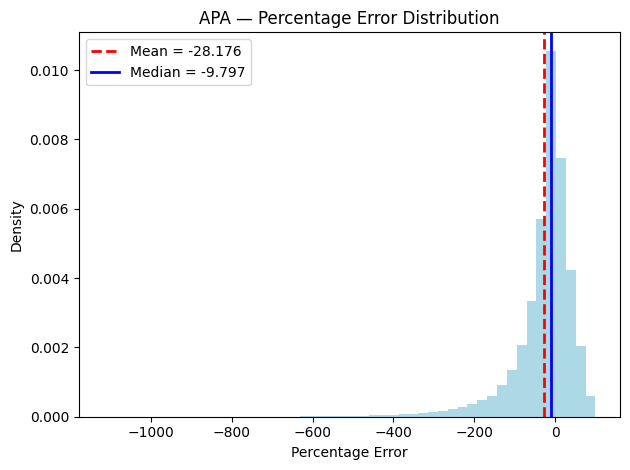

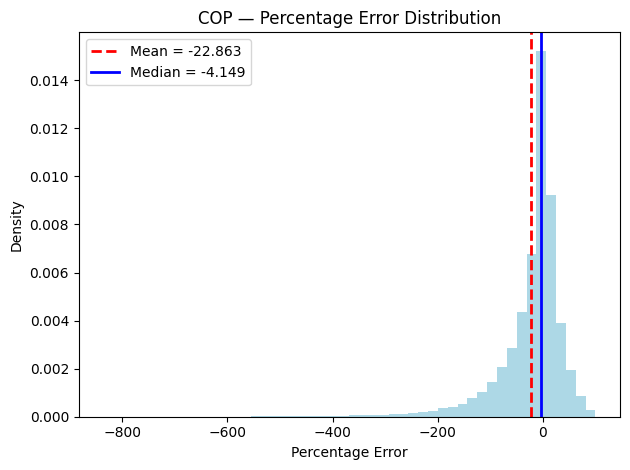

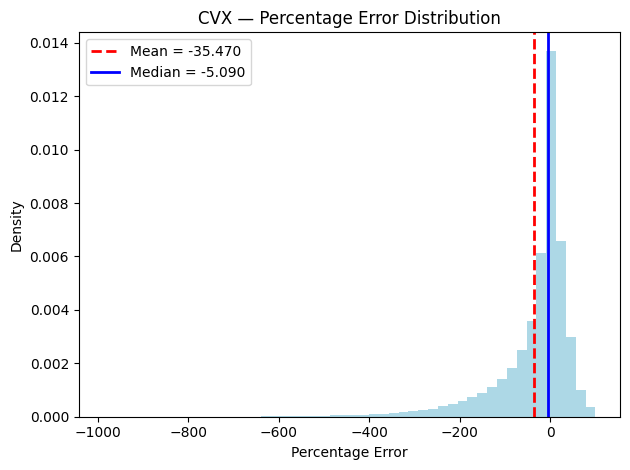

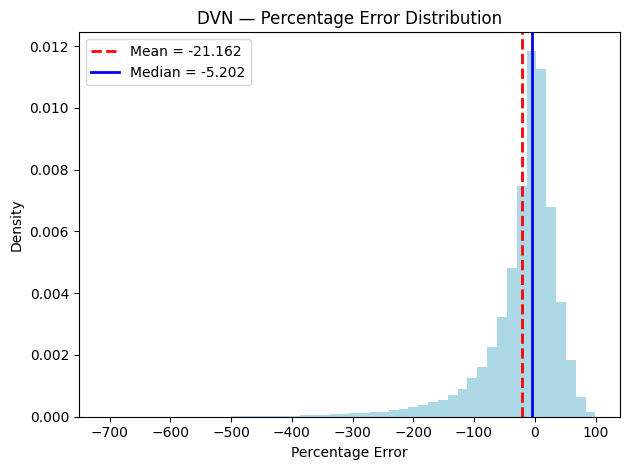

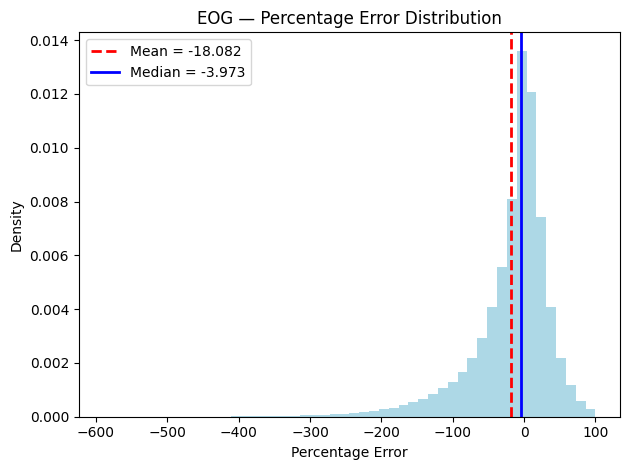

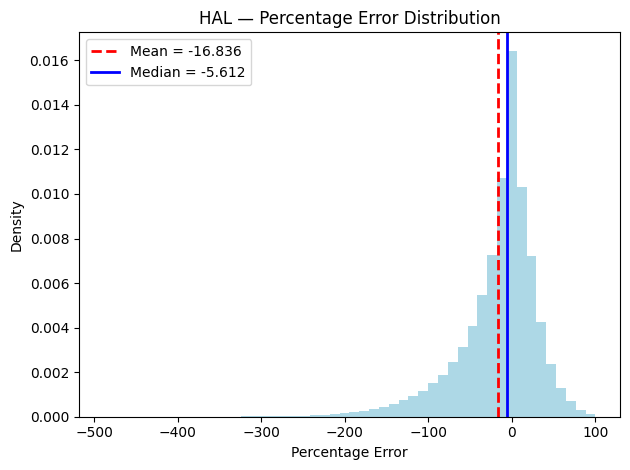

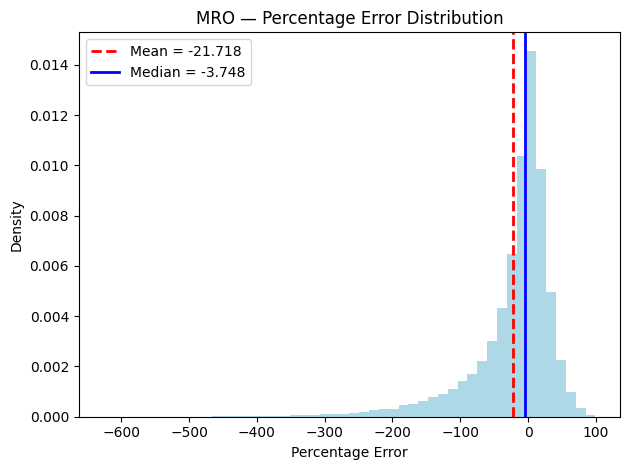

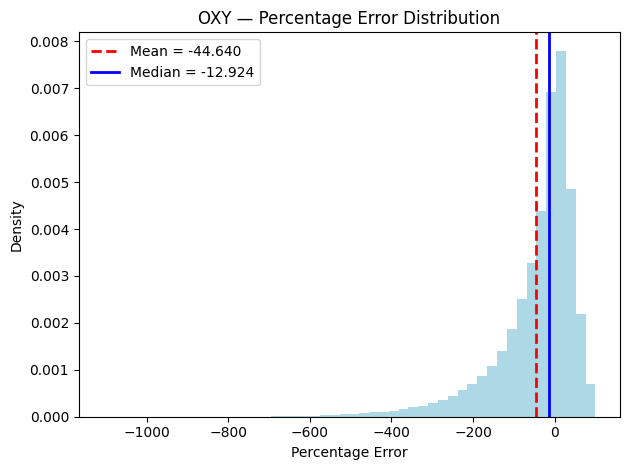

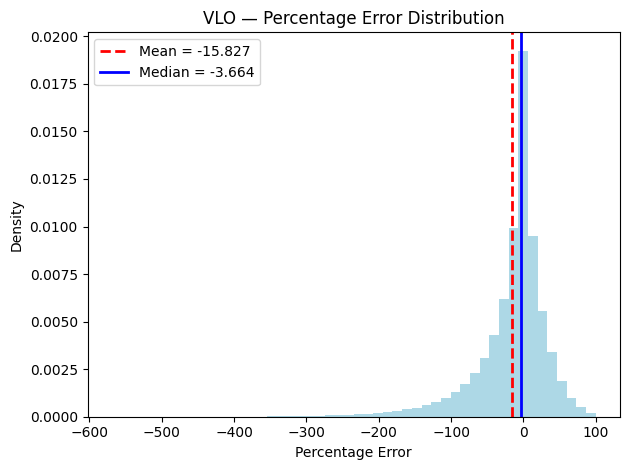

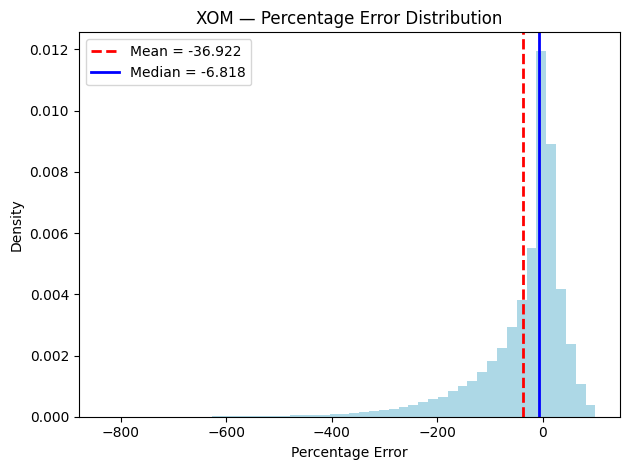

In [9]:
def plot_error_hist(calls_df, save=True):
    """
    Returns a historgrams with %error 
    distribution by ticker.
    
    Given:
    - calls_df      : dataframe input containing %errors.
    - save          : if True, save the plot to disk.
    """
    
    # Set tickers array
    tickers_array = sorted(calls_df["ticker"].unique().tolist())
    
    # Run loop to plot %error histograms per ticker
    for t in tickers_array:
        # Copy dataframe input
        df = calls_df.copy()
        
        # Filter for one ticker per loop 
        df = df[df['ticker'] == t].copy()
        
        # Get mean %error
        mean   = df['%error'].mean()
        # Get median %error
        median = df['%error'].median()

        # Plot histogram
        plt.figure()
        plt.hist(df['%error'], bins=50, density=True, color='lightblue')
        
        # Plot vertical line at mean
        plt.axvline(mean, linewidth=2, linestyle='--', color='red', label=f'Mean = {mean : .3f}')
        # Plot vertical line at median
        plt.axvline(median, linewidth=2, linestyle='-', color='blue', label=f'Median = {median : .3f}')
        
        # Set axis labels
        plt.xlabel('Percentage Error')
        plt.ylabel('Density')
        # Set title
        plt.title(f'{t} — Percentage Error Distribution')
        # Set lables
        plt.legend()
        # Set layout
        plt.tight_layout()
    
    
        # Save only if requested
        if save:
            # Set folder to store plots
            output_dir = "error_histograms"
            os.makedirs(output_dir, exist_ok=True)
            # Save plots as png in a directory
            save_path = os.path.join(output_dir, f"{t}_error_hist.png")
            plt.savefig(save_path, dpi=300)

        # Show plots
        plt.show()
        plt.close()

plot_error_hist(calls_df, save=save_plt)

## Plot Pricing Error vs. Moneyness (Fig. 6)

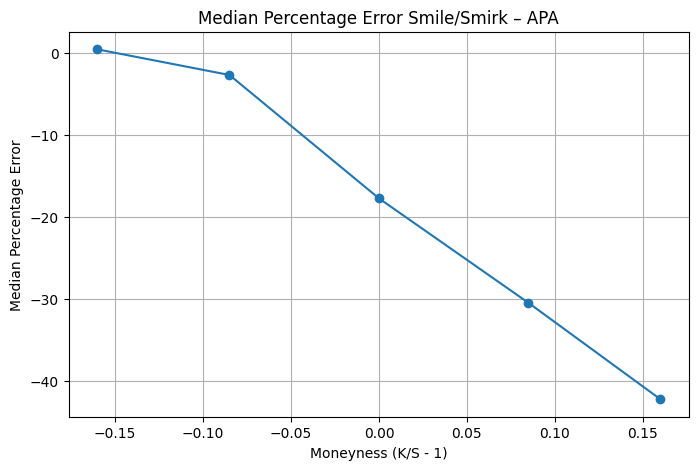

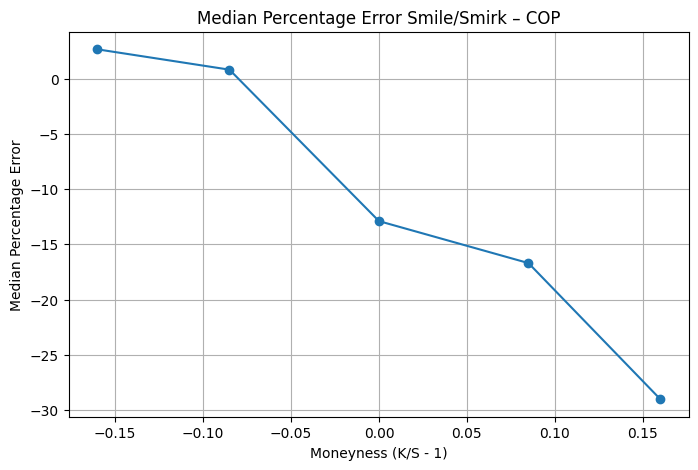

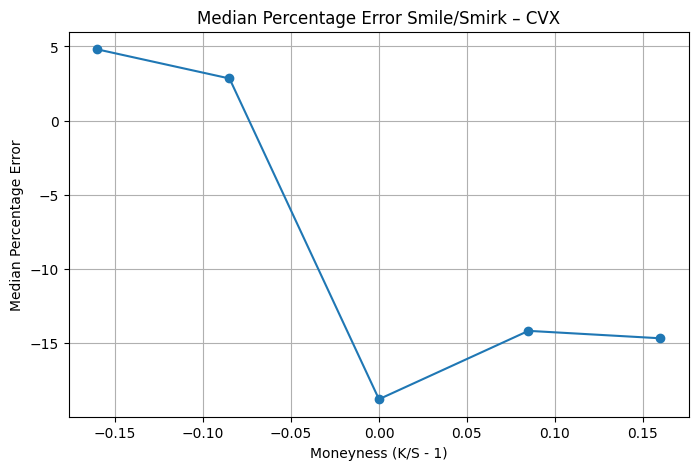

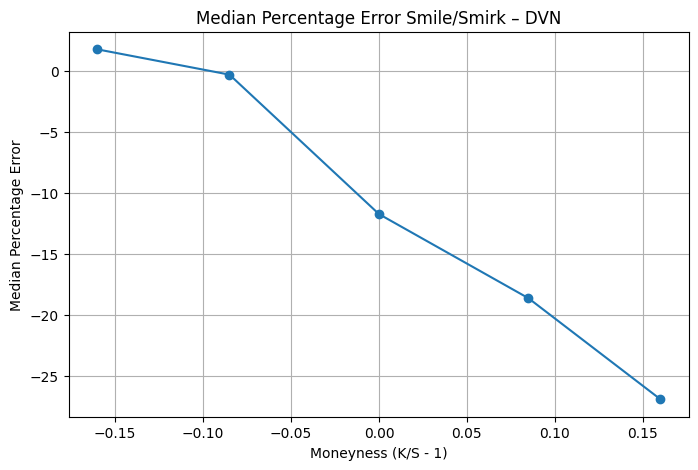

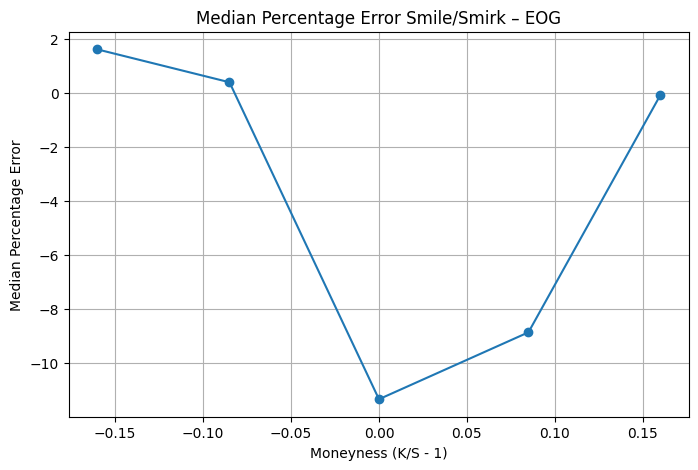

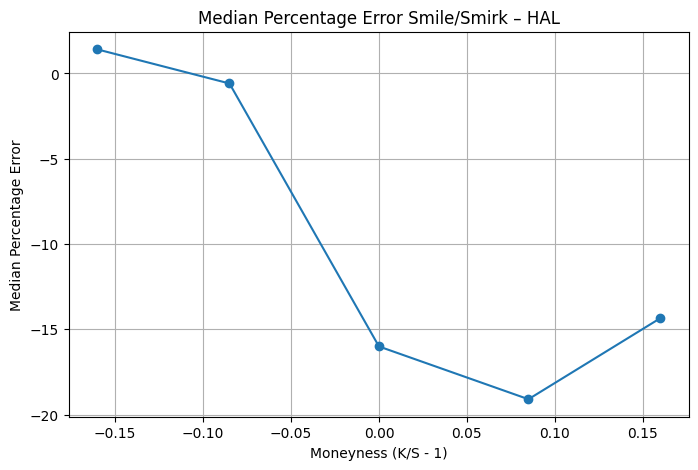

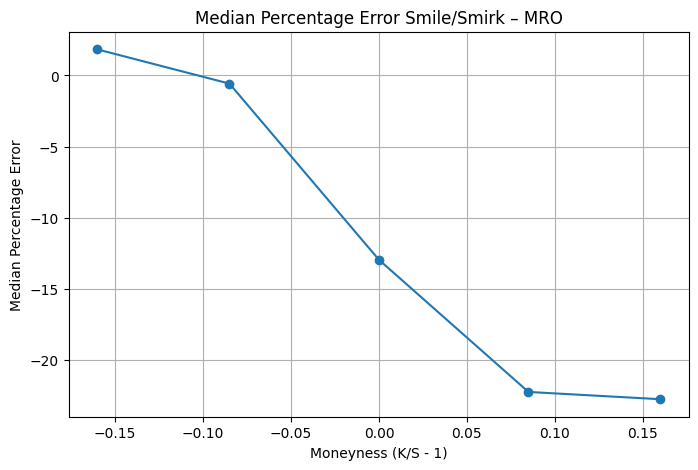

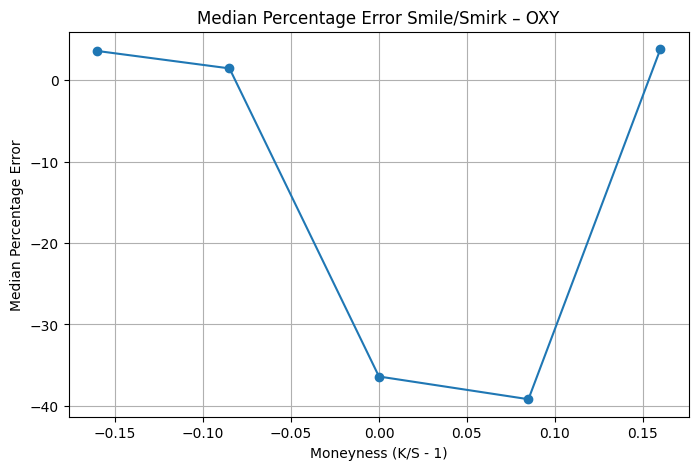

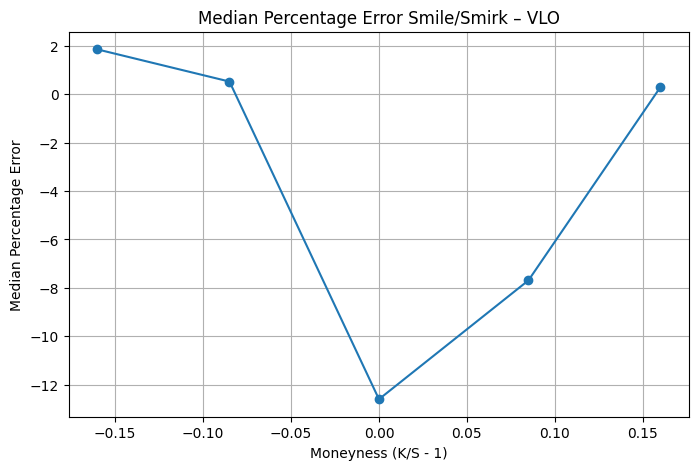

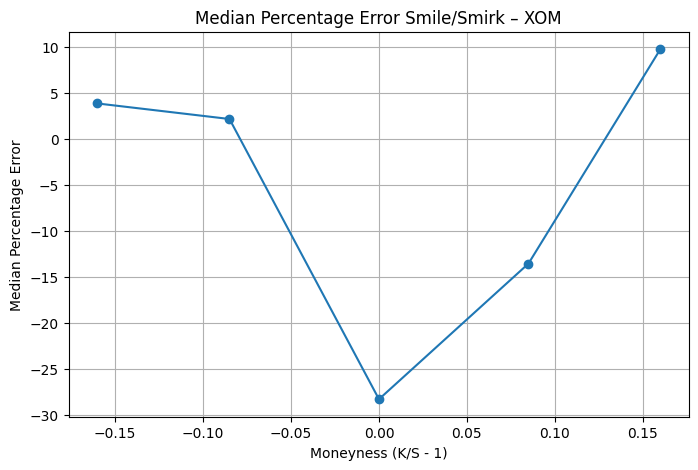

In [10]:
# Set helper function to plot %errors vs moneyness
def plot_error_smile(df,
                     ticker=None, 
                     save=True,
                     bins=None,
                     use_median=True):
    """
    Returns plots of median percentage error using binned moneyness.
    
    Given:
    - df         : dataFrame inputs
    - ticker     : optional ticker symbol to filter df (string). If None, uses all rows.
    - save       : if True, save the plot to disk
    - bins       : moneyness bin edges; default = [-0.20, -0.12, -0.05, 0.05, 0.12, 0.20]
    - use_median : if True use median %error per bin, else mean %error
    """

    # Set moneyness bins for plotting
    if bins is None:
        bins = [-0.20, -0.12, -0.05, 0.05, 0.12, 0.20]

    # Optionally filter by ticker
    data = df.copy()
    if ticker is not None:
        data = data[data['ticker'] == ticker].copy()

    # Set moneyness bins in the dataframe
    data['moneyness_bin'] = pd.cut(
        data['%moneyness'],
        bins=bins,
        include_lowest=True,
        right=True
    )

    # Aggregate %error within each bin
    agg_func = 'median' if use_median else 'mean'
    smile = (
        data.groupby('moneyness_bin', observed=True)['%error']
            .agg(error=agg_func)
            .reset_index()
    )

    # Compute bin midpoints for x-axis
    smile['moneyness_mid'] = smile['moneyness_bin'].apply(
        lambda iv: (iv.left + iv.right) / 2
    )

    # Drop bins with no data (NaN errors)
    smile = smile.dropna(subset=['error'])

    # Plot moneyness bins and %error
    plt.figure(figsize=(8, 5))
    plt.plot(smile['moneyness_mid'], smile['error'], marker='o')

    # Set title
    title_tkr = f" – {ticker}" if ticker is not None else ""
    stat_label = "Median" if use_median else "Mean"
    plt.title(f"{stat_label} Percentage Error Smile/Smirk{title_tkr}")
    
    # Set axis labels
    plt.xlabel("Moneyness (K/S - 1)")
    plt.ylabel(f"{stat_label} Percentage Error")
    
    # Set grid
    plt.grid(True)
    
    # Save only if requested
    if save:
        # Set folder to store plots
        output_dir = "error_moneyness"
        os.makedirs(output_dir, exist_ok=True)
        # Save plots as pnd in directory
        save_path = os.path.join(output_dir, f"{t}_error_money.png")
        plt.savefig(save_path, dpi=300)
    
    # Show plots
    plt.show()

# Run loop per ticker to get plots
for t in tickers_array:
    plot_error_smile(calls_df, ticker=t, save=save_plt)

## Plot Error vs. Maturity by Moneyness (Fig. 7)

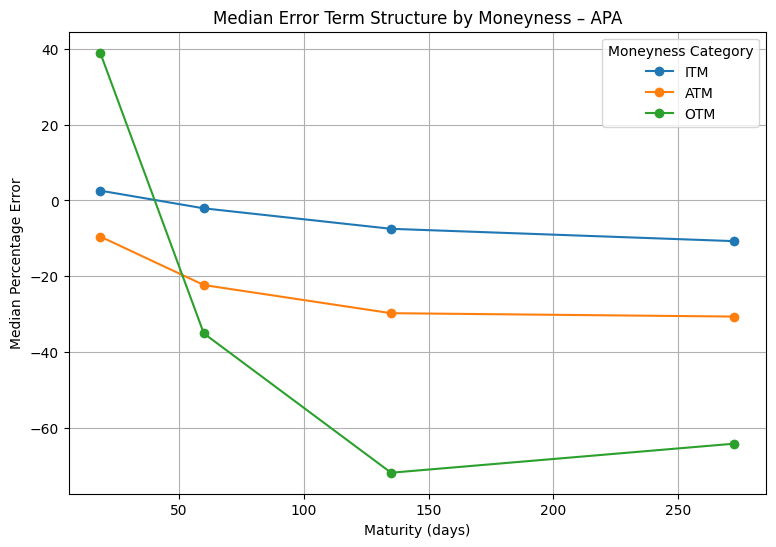

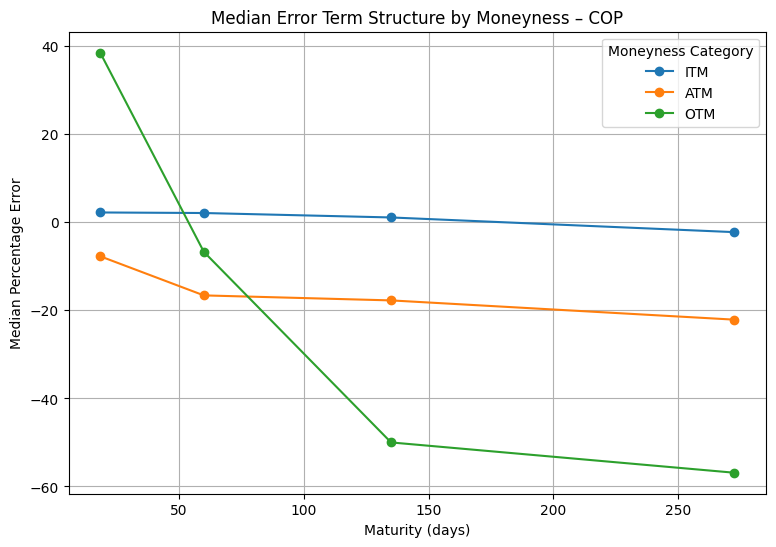

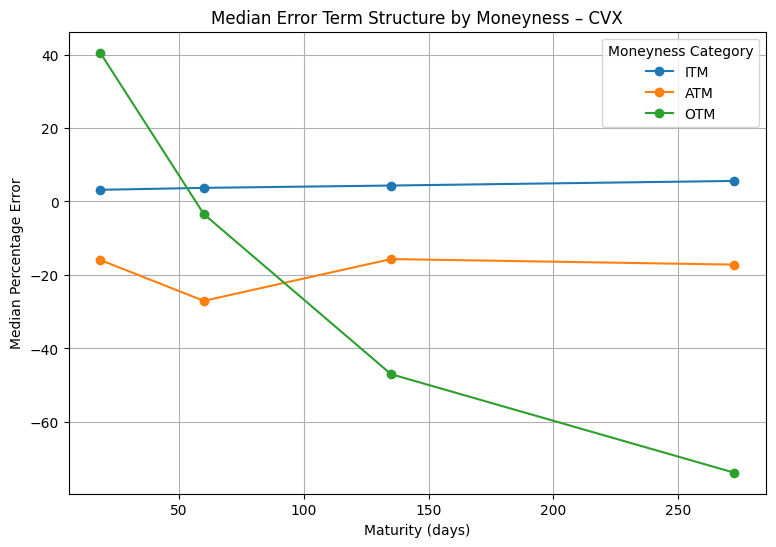

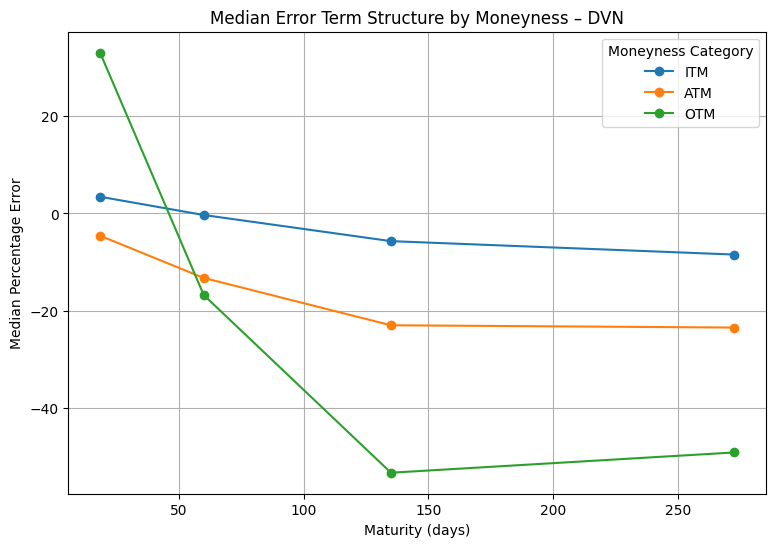

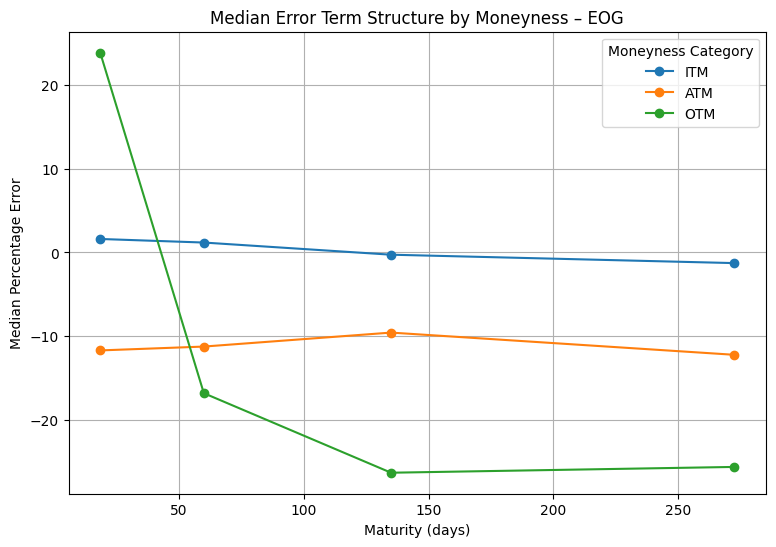

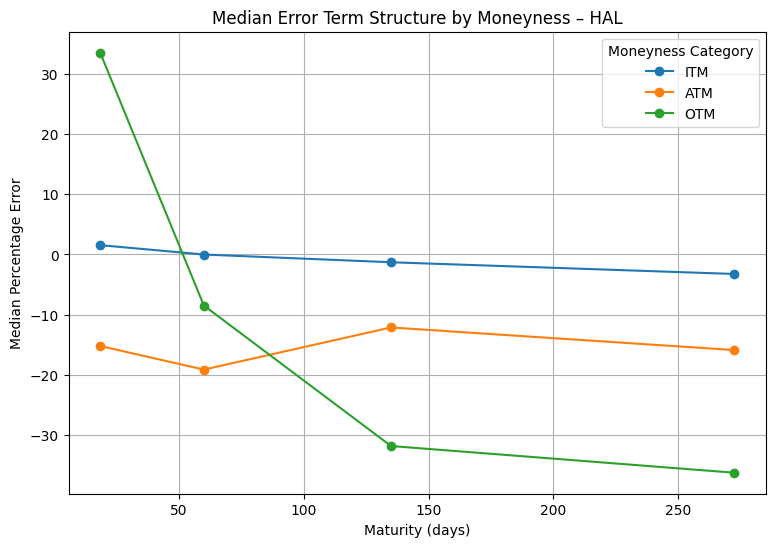

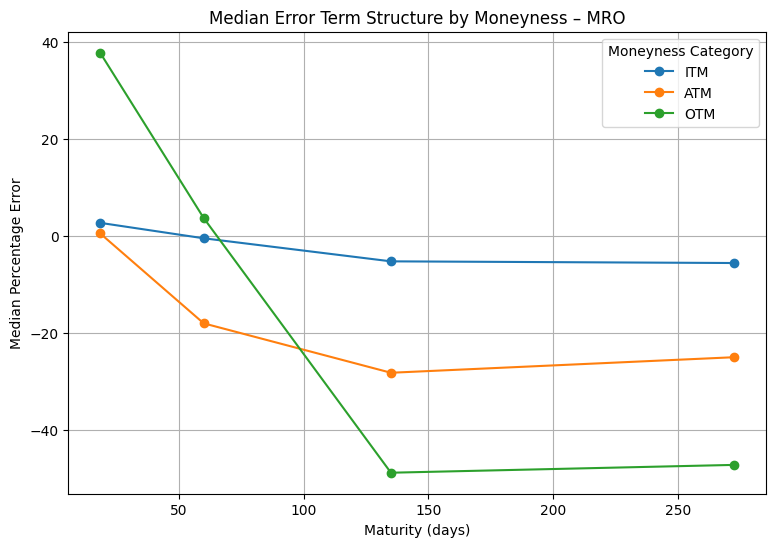

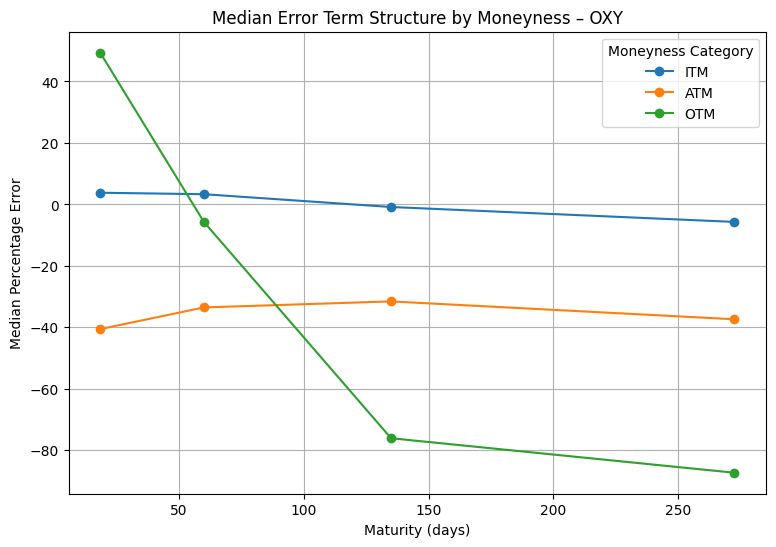

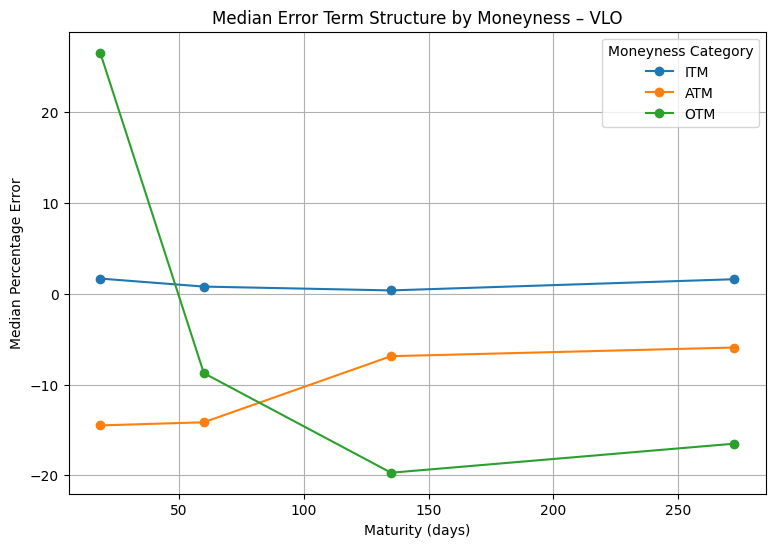

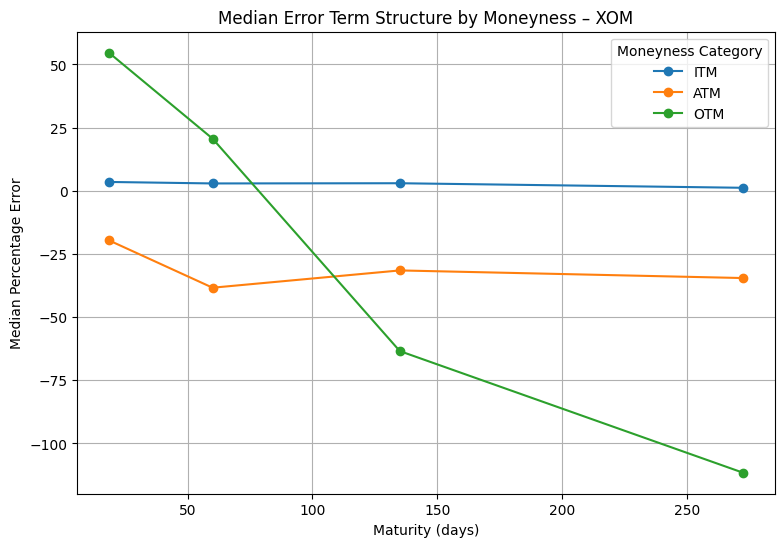

In [11]:
def plot_error_by_moneyness(df, 
                            ticker=None,
                            save=True,
                            maturity_bins=None,
                            maturity_labels=None,
                            use_median=True):
    """
    Returns a plot with median percentage error lines vs. maturity 
    by moneyness categories: ITM, ATM, OTM.
    
    Given:
    - df             : dataframe input
    - ticker         : optional ticker symbol to filter df (string). If None, uses all rows.
    - save           : if True, save the plot to disk
    - maturity_bins  : list of day boundaries for maturity buckets
    - maturity_labels: labels for the maturity buckets
    - use_median     : if True use median error, else mean.
    """
    
    # Set maturity bins
    if maturity_bins is None:
        maturity_bins = [7, 30, 90, 180, 365]
    # Set maturity labels
    if maturity_labels is None:
        maturity_labels = ['Short-Term', 'Medium', 'Longer-Term', '1-Year']

    # Copy dataframe input
    data = df.copy()
    
    # Option ticker filter
    if ticker is not None:
        data = data[data['ticker'] == ticker].copy()

    # Set maturity 'buckets'
    data['maturity_bucket'] = pd.cut(
        data['maturity_days'],
        bins=maturity_bins,
        labels=maturity_labels,
        include_lowest=True
    )

    # Set moneyness categories
    # ITM  < −5%
    # ATM  −5% to +5%
    # OTM  > +5%
    conditions = [
        (data['%moneyness'] < -0.05),
        (data['%moneyness'].between(-0.05, 0.05)),
        (data['%moneyness'] > 0.05)
    ]
    categories = ['ITM', 'ATM', 'OTM']

    data['moneyness_cat'] = np.select(conditions, categories, default='Unknown')

    # Aggregate errors by median or mean
    agg_func = 'median' if use_median else 'mean'

    grouped = (
        data.groupby(['maturity_bucket', 'moneyness_cat'], observed=True)['%error']
            .agg(agg_func)
            .reset_index(name='%error')
    )

    # Get midpoints for x-axis
    mids = {
        maturity_labels[i]: (maturity_bins[i] + maturity_bins[i+1]) / 2
        for i in range(len(maturity_labels))
    }
    grouped['mid'] = grouped['maturity_bucket'].map(mids)

    # Plot %error vs. maturity grouped by moneyness
    plt.figure(figsize=(9, 6))
    
    # Run loop to group dataframe by moneyness
    for cat in ['ITM', 'ATM', 'OTM']:
        plot_df = grouped[grouped['moneyness_cat'] == cat]
        # Safeguard for empty dataframe
        if plot_df.empty:
            continue
        
        # Plot %error vs. maturity
        plt.plot(plot_df['mid'], plot_df['%error'], marker='o', label=cat)

    # Set title
    tkr_label = f" – {ticker}" if ticker is not None else ""
    stat_label = "Median" if use_median else "Mean"
    plt.title(f"{stat_label} Error Term Structure by Moneyness{tkr_label}")
    
    # Set axis labels
    plt.xlabel("Maturity (days)")
    plt.ylabel(f"{stat_label} Percentage Error")
    
    # Set label
    plt.legend(title="Moneyness Category")
    
    # Set grid
    plt.grid(True)
    
    # Save only if requested
    if save:
    # Set folder to store plots
        output_dir = "error_structure"
        os.makedirs(output_dir, exist_ok=True)
        # Save plots as pnd in a directory
        save_path = os.path.join(output_dir, f"{t}_error_structure.png")
        plt.savefig(save_path, dpi=300)
    
    # Show plots
    plt.show()

# Run loop to get plots per ticker
for t in tickers_array:
    plot_error_by_moneyness(calls_df, ticker=t, save=save_plt)

## Plot Median Percentage Error and Crude Oil Prices with Oil Volatility (Fig.8)

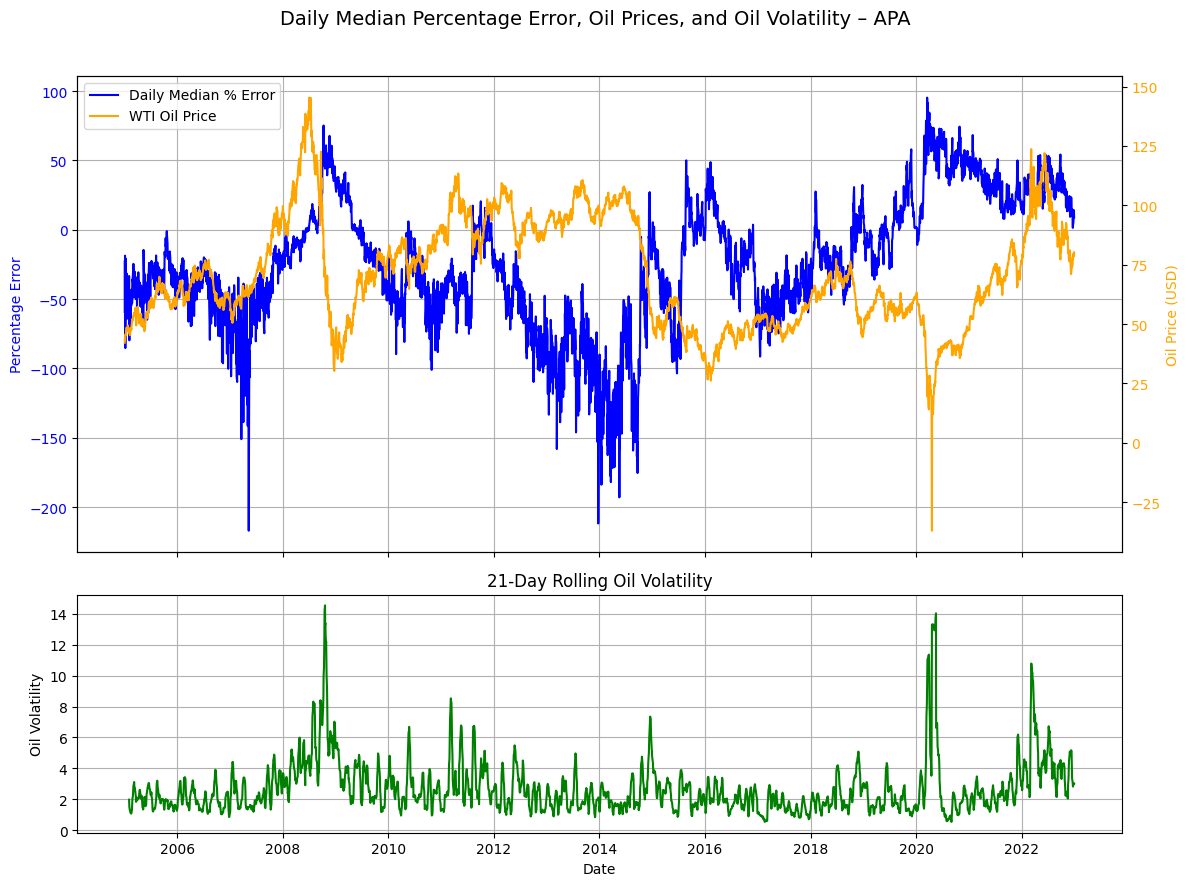

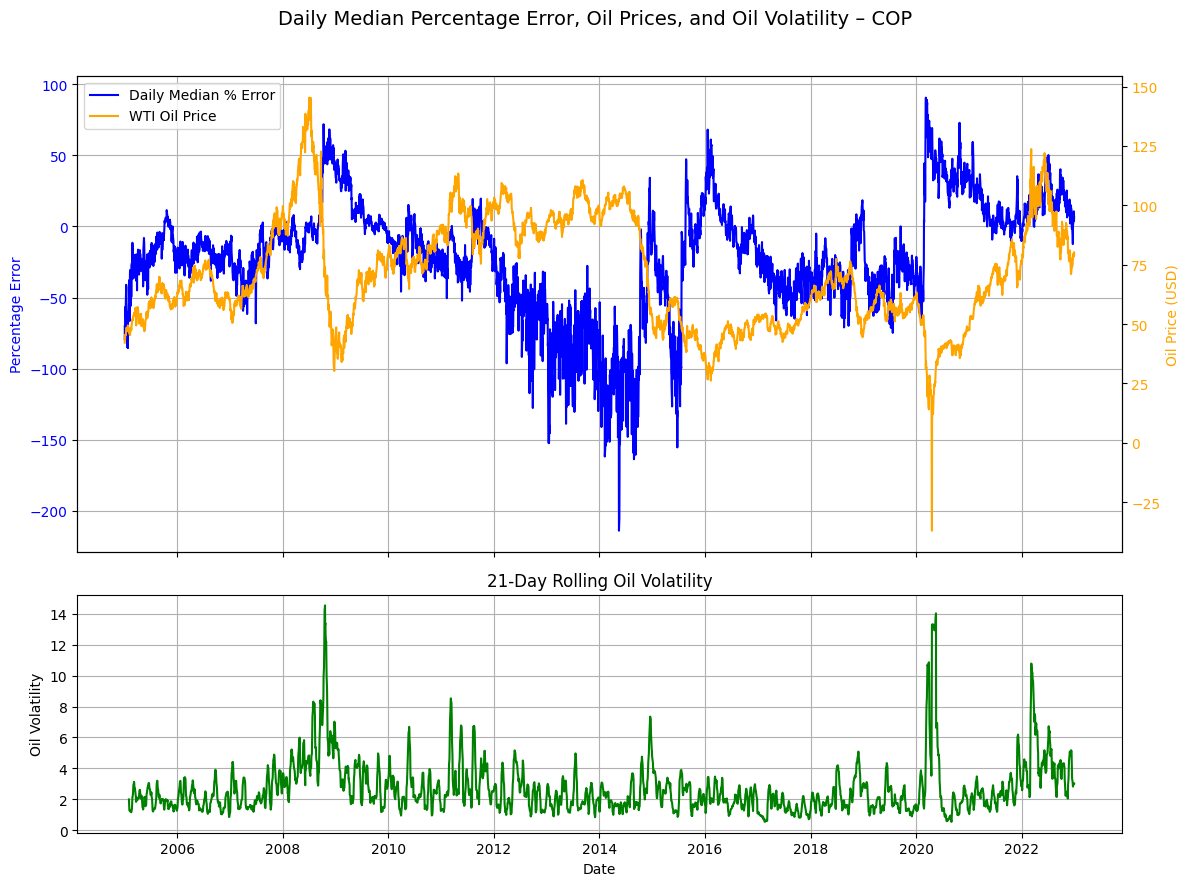

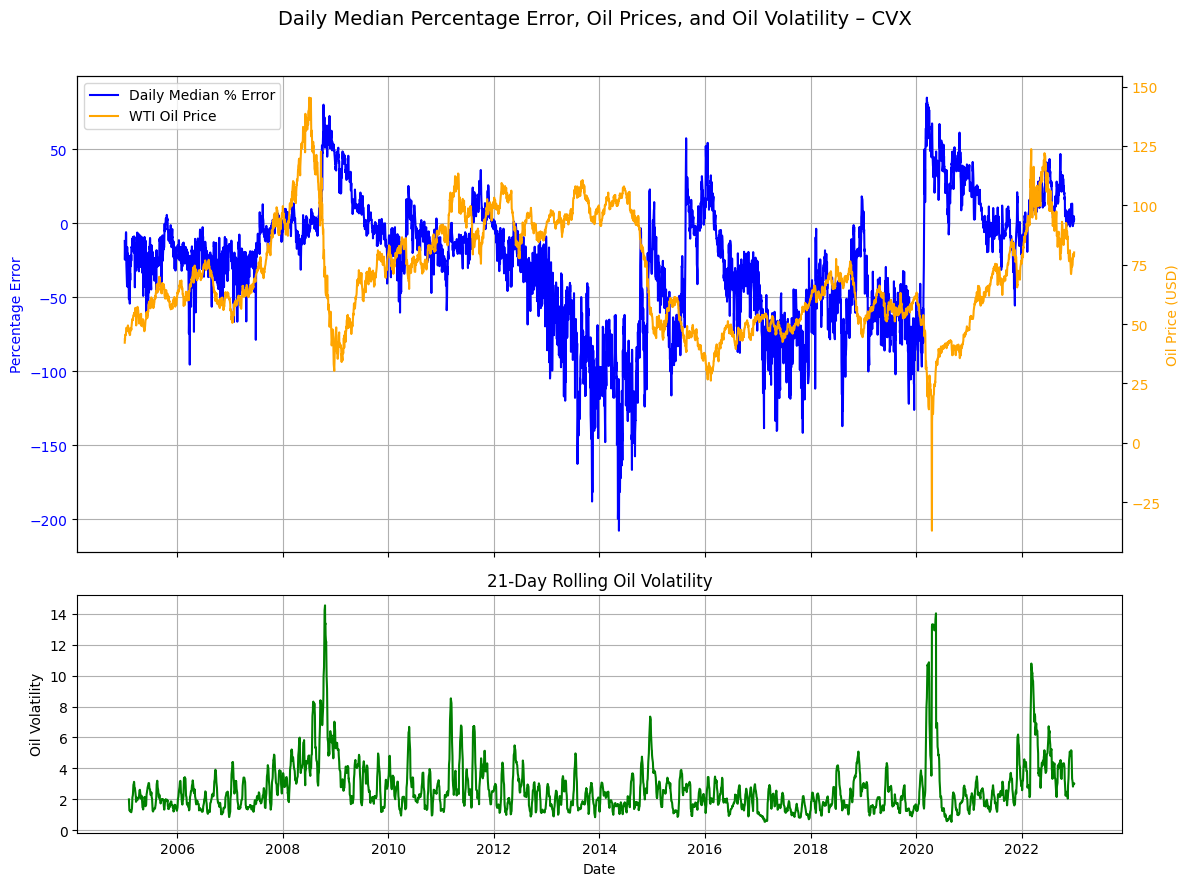

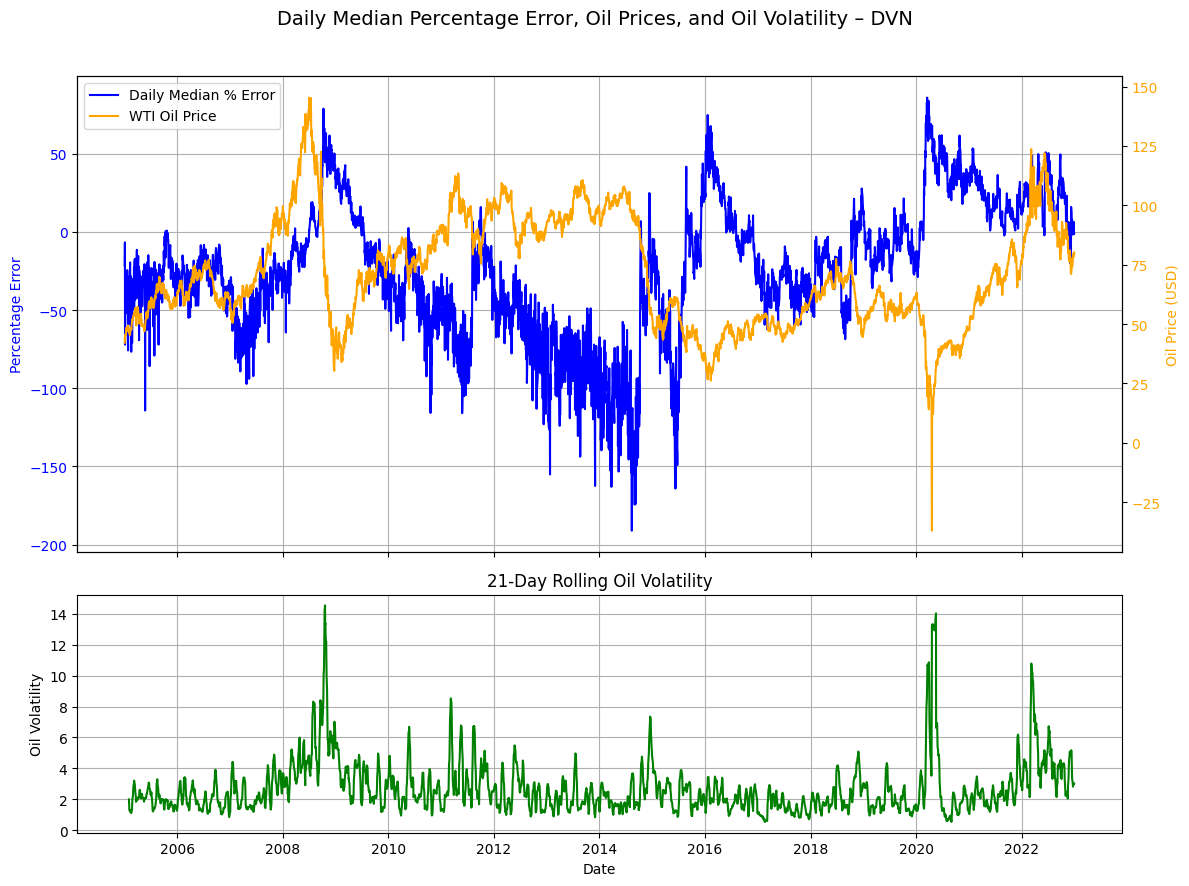

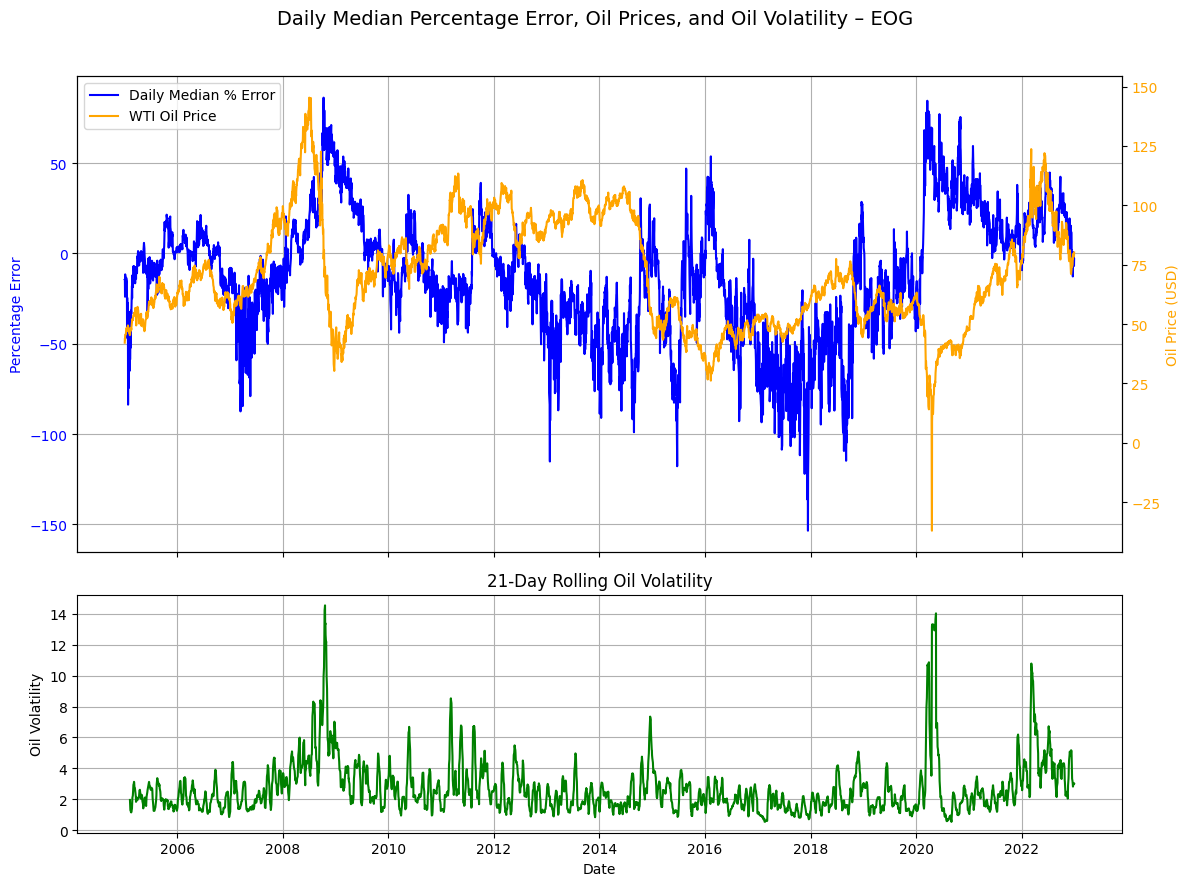

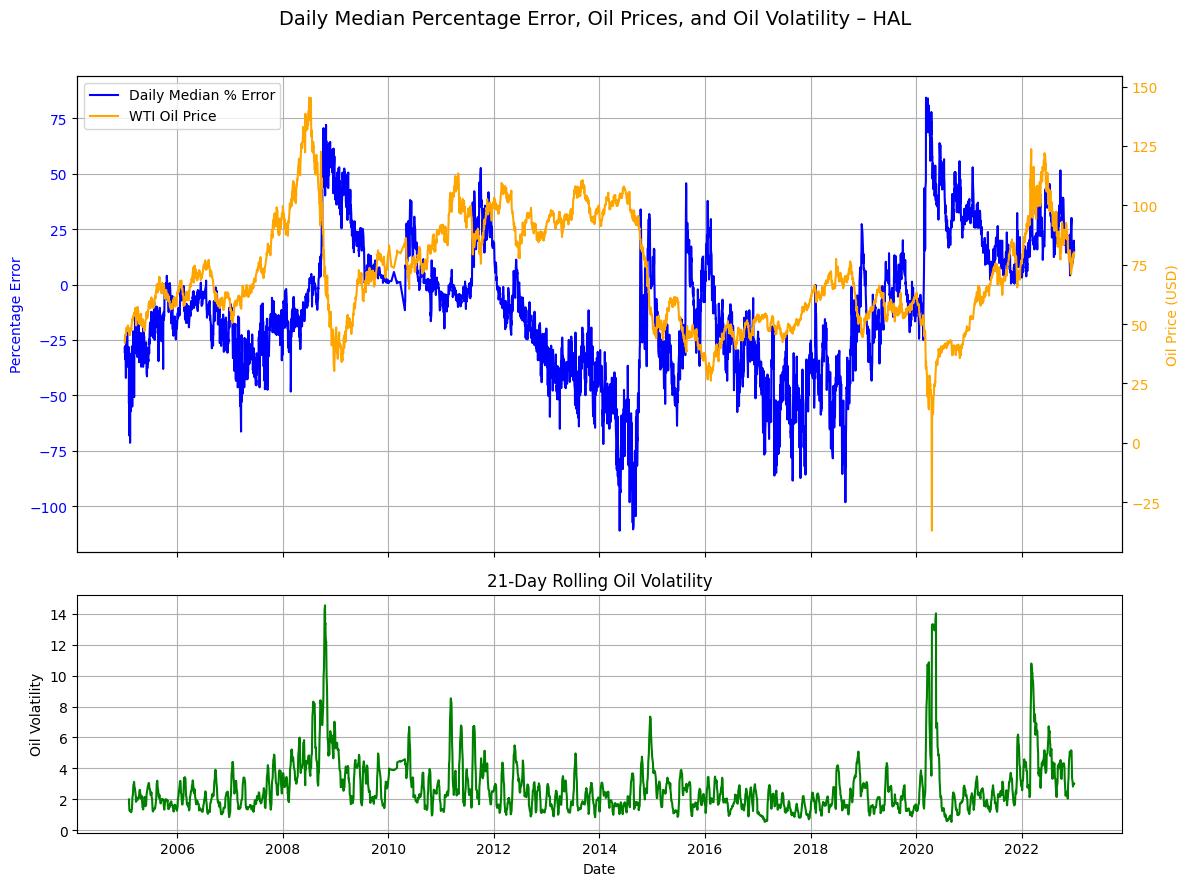

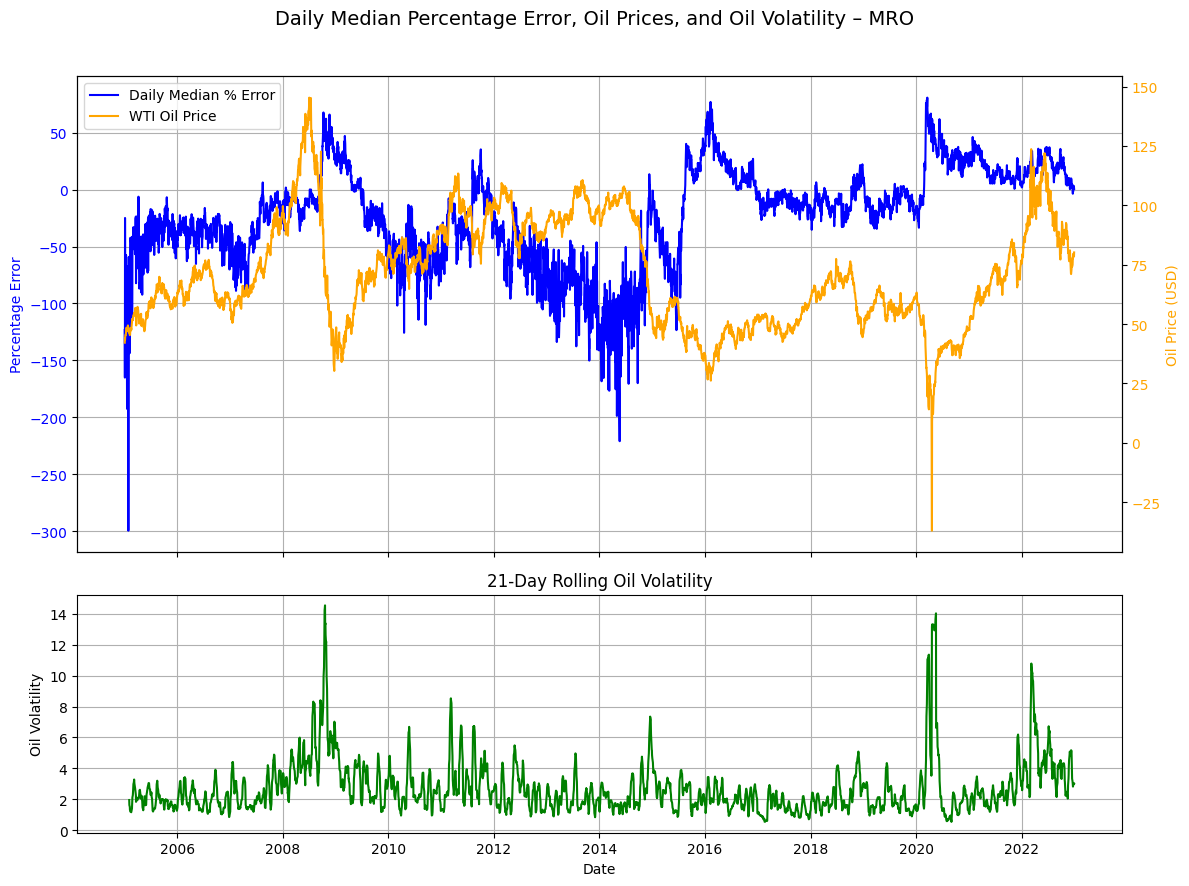

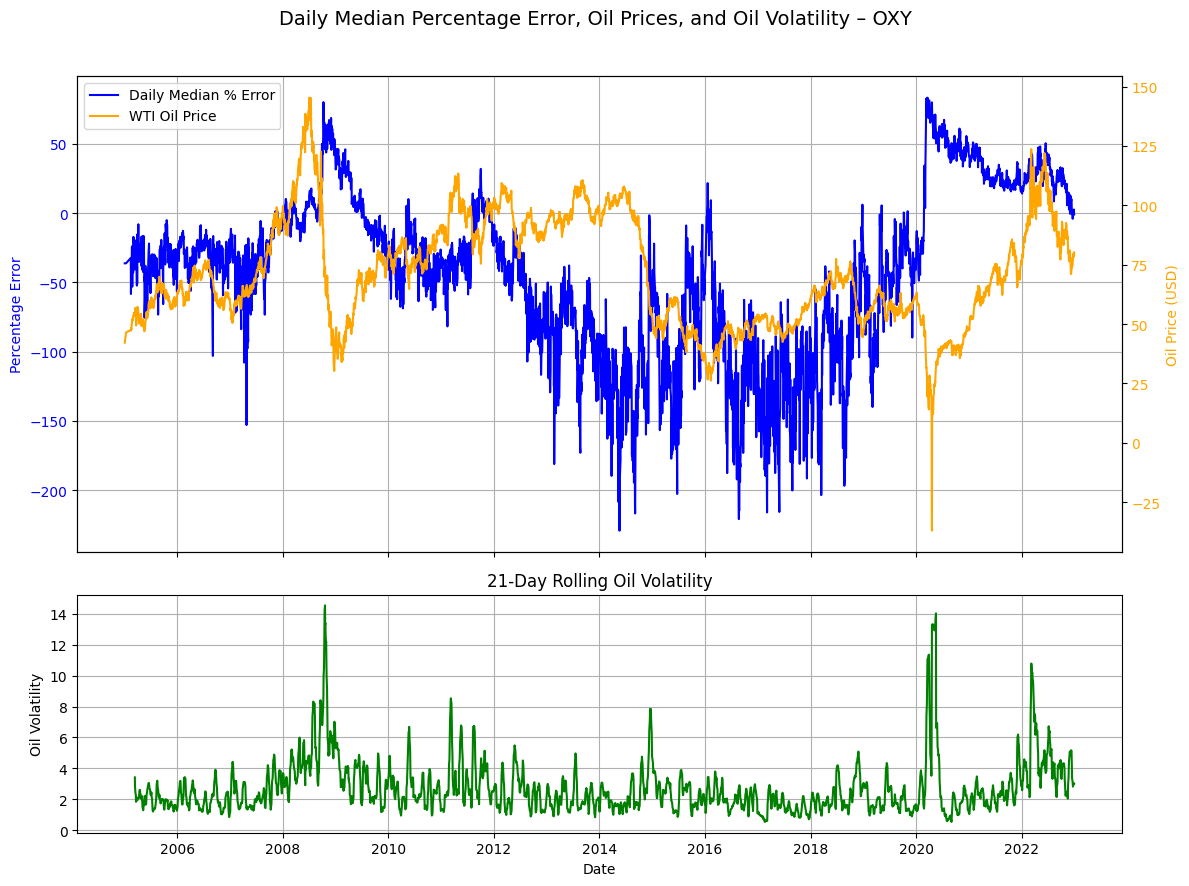

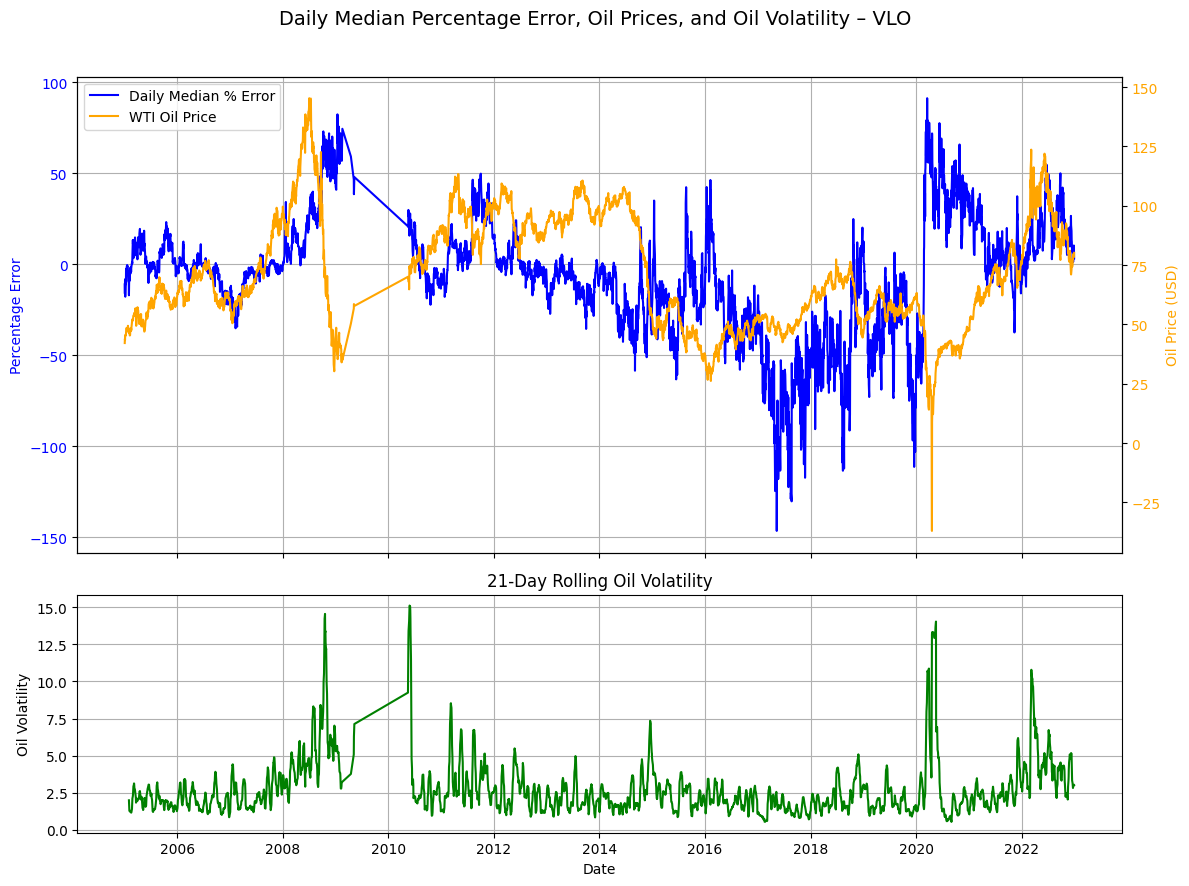

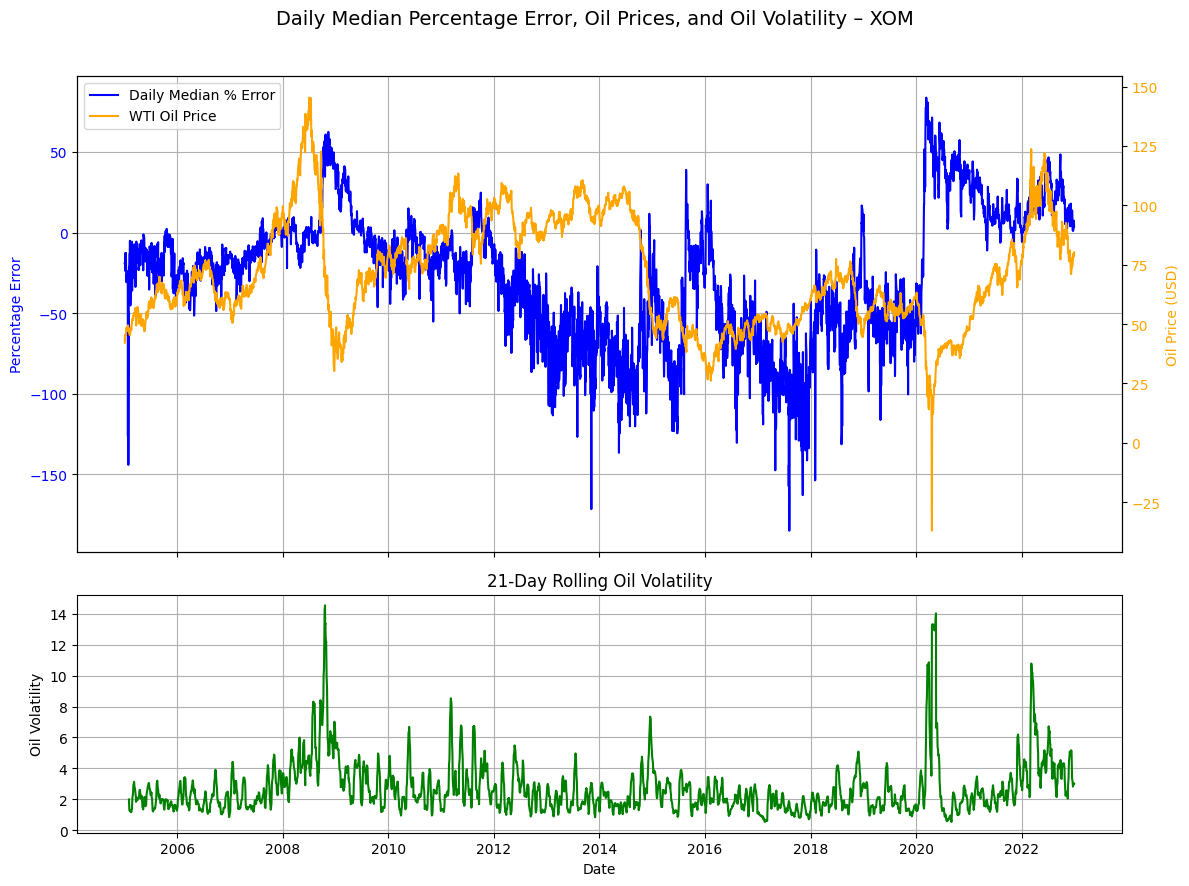

In [12]:
# Read csv file with crude oil prices
oil_prices = pd.read_csv('DCOILWTICO.csv').dropna()

# Rename columns
oil_prices.rename(columns={'observation_date': 'date',
                           'DCOILWTICO': 'oil_prices'}, inplace=True)

# Ensure pandas datetime
oil_prices['date'] = pd.to_datetime(oil_prices['date'])

# Set only desired variables
error_df = calls_df[['date', 'ticker', '%error']].copy()
error_df['date'] = pd.to_datetime(error_df['date'])

# Merge oil prices with error dataframe
oil_error = pd.merge(
    error_df,
    oil_prices,
    on='date',
    how='inner'
)

def plot_error_oil_and_volatility(df,
                                  ticker=None,
                                  save=True,
                                  error_col='%error',
                                  use_median=True,
                                  oil_col='oil_prices',
                                  vol_window=21):
    """
    Plots:
    1. Daily median (or mean) percentage pricing error with crude oil prices
    2. Oil volatility time series below

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing date, ticker, percentage error, and oil price.
    ticker : str or None
        If provided, filter data for one ticker only.
    save : bool
        If True, save the plot.
    error_col : str
        Column name for pricing error.
    use_median : bool
        If True uses median daily error, otherwise mean.
    oil_col : str
        Column name for oil prices.
    vol_window : int
        Rolling window length used to compute oil volatility.
    """

    # Copy dataframe
    data = df.copy()

    # Filter by ticker if requested
    if ticker is not None:
        data = data[data['ticker'] == ticker]

    # Ensure datetime
    data['date'] = pd.to_datetime(data['date'])

    # Choose aggregation for pricing error
    agg_func = 'median' if use_median else 'mean'

    # Daily aggregated pricing error
    daily_error = (
        data.groupby('date', observed=True)[error_col]
            .agg(agg_func)
            .reset_index(name='daily_error')
    )

    # Daily oil price
    daily_oil = (
        data.groupby('date', observed=True)[oil_col]
            .mean()
            .reset_index(name='oil_price')
    )

    # Merge error and oil price
    daily = pd.merge(daily_error, daily_oil, on='date', how='inner').sort_values('date')

    # Compute oil volatility from daily oil price
    oil_vol = daily[['date', 'oil_price']].copy()
    oil_vol['oil_volatility'] = oil_vol['oil_price'].rolling(window=vol_window).std(ddof=1)
    oil_vol = oil_vol.dropna(subset=['oil_volatility'])

    # Create figure with two stacked panels
    fig, (ax1, ax3) = plt.subplots(
        2, 1,
        figsize=(12, 9),
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # Top plot: pricing error + oil price
    l1, = ax1.plot(
        daily['date'],
        daily['daily_error'],
        color='blue',
        label=f'Daily {agg_func.capitalize()} % Error'
    )
    ax1.set_ylabel("Percentage Error", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True)

    ax2 = ax1.twinx()
    l2, = ax2.plot(
        daily['date'],
        daily['oil_price'],
        color='orange',
        label='WTI Oil Price'
    )
    ax2.set_ylabel("Oil Price (USD)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    ax1.legend(handles=[l1, l2], loc='upper left', frameon=True)

    # Bottom plot: oil volatility
    ax3.plot(
        oil_vol['date'],
        oil_vol['oil_volatility'],
        color='green',
        label=f'{vol_window}-Day Rolling Oil Volatility'
    )
    ax3.set_xlabel("Date")
    ax3.set_ylabel("Oil Volatility")
    ax3.set_title(f'{vol_window}-Day Rolling Oil Volatility')
    ax3.grid(True)

    # Main title
    ticker_suffix = f" – {ticker}" if ticker else ""
    fig.suptitle(f"Daily {agg_func.capitalize()} Percentage Error, Oil Prices, and Oil Volatility{ticker_suffix}",
                 fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save if requested
    if save:
        output_dir = "time_error"
        os.makedirs(output_dir, exist_ok=True)

        file_name = f"{ticker}_combined_time_error.png" if ticker else "combined_time_error.png"
        save_path = os.path.join(output_dir, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# Run loop to get plots per ticker
for t in tickers_array:
    plot_error_oil_and_volatility(
        oil_error,
        ticker=t,
        save=save_plt,
        use_median=True
    )